# Datathon 2026 - Exploratory Data Analysis (EDA)

This notebook builds a complete EDA workflow for the Datathon 2026 dataset using only the provided CSV files.

The analysis follows a business storytelling flow:

1. **Data cleaning** - make the tables trustworthy before analysis.
2. **Data joining** - create analysis-ready fact tables.
3. **Descriptive analysis** - understand what happened.
4. **Diagnostic analysis** - investigate why it happened.
5. **Predictive insights** - detect patterns and leading indicators without forecasting.
6. **Prescriptive insights** - translate findings into business actions.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("data")
PLOT_SIZE = (12, 5)

def finish_plot(title, xlabel=None, ylabel=None, legend=True, rotation=0):
    # A consistent plot helper keeps every chart readable and presentation-friendly.
    plt.title(title, fontsize=14, weight="bold")
    if xlabel is not None:
        plt.xlabel(xlabel)
    if ylabel is not None:
        plt.ylabel(ylabel)
    if rotation:
        plt.xticks(rotation=rotation, ha="right")
    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        if handles:
            plt.legend(frameon=False)
    else:
        leg = plt.gca().get_legend()
        if leg is not None:
            leg.remove()
    plt.tight_layout()
    plt.show()

def summarize_missing(df, table_name):
    # Missingness is reported before business-specific handling so assumptions stay visible.
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if missing.empty:
        print(f"{table_name}: no missing values detected.")
    else:
        print(f"{table_name}: missing values")
        display(pd.DataFrame({"missing_count": missing, "missing_pct": missing / len(df)}))

## 0. Data Loading

We load every provided CSV into a dictionary and expose each table as a named DataFrame. This keeps the notebook explicit and prevents accidentally skipping a required dataset.

In [2]:
files = {
    "products": "products.csv",
    "customers": "customers.csv",
    "promotions": "promotions.csv",
    "geography": "geography.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "payments": "payments.csv",
    "shipments": "shipments.csv",
    "returns": "returns.csv",
    "reviews": "reviews.csv",
    "sales": "sales.csv",
    "inventory": "inventory.csv",
    "web_traffic": "web_traffic.csv",
}

missing_files = [name for name, file in files.items() if not (DATA_DIR / file).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required CSV files: {missing_files}")

data = {name: pd.read_csv(DATA_DIR / file) for name, file in files.items()}

products = data["products"].copy()
customers = data["customers"].copy()
promotions = data["promotions"].copy()
geography = data["geography"].copy()
orders = data["orders"].copy()
order_items = data["order_items"].copy()
payments = data["payments"].copy()
shipments = data["shipments"].copy()
returns = data["returns"].copy()
reviews = data["reviews"].copy()
sales = data["sales"].copy()
inventory = data["inventory"].copy()
web_traffic = data["web_traffic"].copy()

summary = pd.DataFrame({
    "table": list(data.keys()),
    "rows": [len(df) for df in data.values()],
    "columns": [df.shape[1] for df in data.values()],
})
display(summary)

,table,rows,columns
0,products,2412,8
1,customers,121930,7
2,promotions,50,10
3,geography,39948,4
4,orders,646945,8
5,order_items,714669,7
6,payments,646945,4
7,shipments,566067,4
8,returns,39939,7
9,reviews,113551,7


In [3]:
for name, df in data.items():
    print(f"\n{name.upper()} - shape={df.shape}")
    display(df.head(3))


PRODUCTS - shape=(2412, 8)


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,"11,059.65","9,704.84"
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,"9,523.08","5,393.87"
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,"15,951.63","11,371.92"



CUSTOMERS - shape=(121930, 7)


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search



PROMOTIONS - shape=(50, 10)


...

,Date,Revenue,COGS
0,2012-07-04,"5,123,547.94","3,982,991.19"
1,2012-07-05,"2,751,773.45","2,150,580.23"
2,2012-07-06,"3,054,029.42","2,517,632.84"



INVENTORY - shape=(60247, 17)


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.00,0.93,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.00,0.97,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.00,0.97,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,12



WEB_TRAFFIC - shape=(3652, 7)


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.01,102.90,organic_search
1,2013-01-02,10456,8151,47611,0.00,120.50,organic_search
2,2013-01-03,10076,7458,36963,0.00,263.60,direct


# Step 1 - Data Cleaning

The goal is not to delete imperfect records blindly. Instead, we standardize types, resolve invalid duplicates, create business flags for missing relationships, and surface quality issues that may affect interpretation.

## 1.1 Data Types

Date columns are converted to datetime so we can aggregate by day, month, and period correctly. Numeric columns are converted using safe coercion so invalid values become `NaN` and can be inspected.

In [4]:
date_columns = {
    "customers": ["signup_date"],
    "promotions": ["start_date", "end_date"],
    "orders": ["order_date"],
    "shipments": ["ship_date", "delivery_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "sales": ["Date"],
    "inventory": ["snapshot_date"],
    "web_traffic": ["date"],
}

for table_name, cols in date_columns.items():
    df = globals()[table_name]
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

numeric_columns = {
    "products": ["product_id", "price", "cogs"],
    "customers": ["customer_id", "zip"],
    "geography": ["zip"],
    "orders": ["order_id", "customer_id", "zip"],
    "order_items": ["order_id", "product_id", "quantity", "unit_price", "discount_amount"],
    "payments": ["order_id", "payment_value", "installments"],
    "shipments": ["order_id", "shipping_fee"],
    "returns": ["order_id", "product_id", "return_quantity", "refund_amount"],
    "reviews": ["order_id", "product_id", "customer_id", "rating"],
    "sales": ["Revenue", "COGS"],
    "inventory": ["product_id", "stock_on_hand", "units_received", "units_sold", "stockout_days", "days_of_supply", "fill_rate", "stockout_flag", "overstock_flag", "reorder_flag", "sell_through_rate", "year", "month"],
    "web_traffic": ["sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec"],
}

for table_name, cols in numeric_columns.items():
    df = globals()[table_name]
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

sales = sales.rename(columns={"Date": "date", "Revenue": "revenue", "COGS": "cogs"})
print("Data type conversion complete.")

Data type conversion complete.


## 1.2 Duplicates and Primary Keys

Primary keys should uniquely identify master and transaction records. For `order_items`, duplicate `(order_id, product_id)` rows can represent split lines, so we aggregate them instead of dropping them.

In [5]:
primary_keys = {"products": "product_id", "customers": "customer_id", "orders": "order_id"}

for table_name, key in primary_keys.items():
    df = globals()[table_name]
    duplicate_count = df.duplicated(subset=[key]).sum()
    print(f"{table_name}.{key}: {duplicate_count} duplicate key rows")
    if duplicate_count > 0:
        globals()[table_name] = df.drop_duplicates(subset=[key], keep="first").copy()

order_items["has_promo"] = order_items["promo_id"].notna().astype(int)
order_items["line_revenue"] = order_items["quantity"] * order_items["unit_price"] - order_items["discount_amount"].fillna(0)

before_rows = len(order_items)
item_keys = ["order_id", "product_id"]

# Numeric columns use fast vectorized aggregations. Promo IDs are aggregated separately with first(),
# which skips nulls and avoids slow per-group Python lambdas on the full order_items table.
item_numeric = order_items.groupby(item_keys, as_index=False).agg(
    quantity=("quantity", "sum"),
    unit_price=("unit_price", "mean"),
    discount_amount=("discount_amount", "sum"),
    line_revenue=("line_revenue", "sum"),
    has_promo=("has_promo", "max"),
)

promo_cols = [col for col in ["promo_id", "promo_id_2"] if col in order_items.columns]
if promo_cols:
    item_promos = order_items.groupby(item_keys, as_index=False)[promo_cols].first()
    order_items = item_numeric.merge(item_promos, on=item_keys, how="left")
else:
    order_items = item_numeric

after_rows = len(order_items)
print(f"order_items rows before aggregation: {before_rows:,}")
print(f"order_items rows after aggregation:  {after_rows:,}")


products.product_id: 0 duplicate key rows
customers.customer_id: 0 duplicate key rows
orders.order_id: 0 duplicate key rows
order_items rows before aggregation: 714,669
order_items rows after aggregation:  714,653


## 1.3 Missing Values and Business Flags

Missing values have different meanings by table. Customer demographics can be labeled as unknown, while missing shipments, returns, and reviews often mean that an event did not happen or has not happened yet.

In [6]:
for col in ["gender", "age_group", "acquisition_channel"]:
    if col in customers.columns:
        customers[col] = customers[col].fillna("Unknown")

order_items["has_promo"] = order_items["promo_id"].notna().astype(int)

return_flags = (
    returns.assign(has_return=1)
    .groupby(["order_id", "product_id"], as_index=False)
    .agg(
        has_return=("has_return", "max"),
        return_quantity=("return_quantity", "sum"),
        refund_amount=("refund_amount", "sum"),
        return_reason=("return_reason", lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
    )
)

review_flags = (
    reviews.assign(has_review=1)
    .groupby(["order_id", "product_id"], as_index=False)
    .agg(has_review=("has_review", "max"), rating=("rating", "mean"), review_date=("review_date", "min"))
)

for name, df in {
    "customers": customers,
    "order_items": order_items,
    "shipments": shipments,
    "returns": returns,
    "reviews": reviews,
    "inventory": inventory,
    "web_traffic": web_traffic,
}.items():
    summarize_missing(df, name)

customers: no missing values detected.
order_items: missing values


,missing_count,missing_pct
promo_id_2,714447,1.00
promo_id,438344,0.61


shipments: no missing values detected.
returns: no missing values detected.
reviews: no missing values detected.
inventory: no missing values detected.
web_traffic: no missing values detected.


In [7]:
inventory_issues = {}
for col in ["stock_on_hand", "units_received", "units_sold", "stockout_days", "days_of_supply"]:
    if col in inventory.columns:
        inventory_issues[f"negative_{col}"] = int((inventory[col] < 0).sum())
for col in ["fill_rate", "sell_through_rate"]:
    if col in inventory.columns:
        inventory_issues[f"invalid_{col}"] = int(((inventory[col] < 0) | (inventory[col] > 1)).sum())

traffic_issues = {}
for col in ["sessions", "unique_visitors", "page_views", "avg_session_duration_sec"]:
    if col in web_traffic.columns:
        traffic_issues[f"negative_{col}"] = int((web_traffic[col] < 0).sum())
for col in ["bounce_rate"]:
    if col in web_traffic.columns:
        traffic_issues[f"invalid_{col}"] = int(((web_traffic[col] < 0) | (web_traffic[col] > 1)).sum())

quality_report = pd.DataFrame([
    {"area": "inventory", **inventory_issues},
    {"area": "web_traffic", **traffic_issues},
]).fillna(0)
display(quality_report)

,area,negative_stock_on_hand,negative_units_received,negative_units_sold,negative_stockout_days,negative_days_of_supply,invalid_fill_rate,invalid_sell_through_rate,negative_sessions,negative_unique_visitors,negative_page_views,negative_avg_session_duration_sec,invalid_bounce_rate
0,inventory,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,web_traffic,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## 1.4 Consistency Checks

These checks test whether values agree across tables and business rules. They are not automatically deleted because they may reveal operational or data pipeline issues.

In [8]:
product_margin_issues = products.query("cogs >= price") if {"cogs", "price"}.issubset(products.columns) else pd.DataFrame()
print(f"Products with cogs >= price: {len(product_margin_issues):,}")
display(product_margin_issues.head())

shipment_date_issues = shipments.query("ship_date > delivery_date") if {"ship_date", "delivery_date"}.issubset(shipments.columns) else pd.DataFrame()
print(f"Shipments with ship_date > delivery_date: {len(shipment_date_issues):,}")
display(shipment_date_issues.head())

order_item_totals = order_items.groupby("order_id", as_index=False).agg(item_total=("line_revenue", "sum"))
payment_totals = payments.groupby("order_id", as_index=False).agg(payment_total=("payment_value", "sum"))
payment_check = order_item_totals.merge(payment_totals, on="order_id", how="left")
payment_check["difference"] = payment_check["payment_total"] - payment_check["item_total"]
payment_check["abs_difference"] = payment_check["difference"].abs()

print("Payment reconciliation summary:")
display(payment_check["difference"].describe())
display(payment_check.sort_values("abs_difference", ascending=False).head(10))

Products with cogs >= price: 0


,product_id,product_name,category,segment,size,color,price,cogs


Shipments with ship_date > delivery_date: 0


,order_id,ship_date,delivery_date,shipping_fee


Payment reconciliation summary:


count   646,945.00
mean         -0.00
std           0.00
min          -0.00
25%           0.00
50%           0.00
75%           0.00
max           0.00
Name: difference, dtype: float64

,order_id,item_total,payment_total,difference,abs_difference
489769,631538,"271,911.67","271,911.67",-0.00,0.00
111191,143533,"132,610.73","132,610.73",0.00,0.00
539953,696254,"140,941.89","140,941.89",0.00,0.00
544831,702585,"137,053.77","137,053.77",-0.00,0.00
77767,100323,"146,155.02","146,155.02",-0.00,0.00
622782,803089,"139,095.18","139,095.18",-0.00,0.00
588458,758841,"163,513.70","163,513.70",0.00,0.00
642877,829031,"159,734.05","159,734.05",-0.00,0.00
629972,812421,"132,098.05","132,098.05",-0.00,0.00
555237,715961,"137,701.20","137,701.20",0.00,0.00


# Step 2 - Data Joining

Analysis-ready tables reduce repeated merge logic and make the rest of the notebook easier to follow. The joins keep transaction grain explicit: `fact_orders` is one row per order-product pair.

In [9]:
payments_order = payments.groupby("order_id", as_index=False).agg(
    payment_value=("payment_value", "sum"),
    installments=("installments", "max"),
    payment_method_from_payments=("payment_method", "first"),
)

shipments_order = shipments.groupby("order_id", as_index=False).agg(
    ship_date=("ship_date", "min"),
    delivery_date=("delivery_date", "max"),
    shipping_fee=("shipping_fee", "sum"),
)

fact_orders = (
    order_items
    .merge(orders, on="order_id", how="left")
    .merge(products, on="product_id", how="left", suffixes=("", "_product"))
    .merge(customers, on="customer_id", how="left", suffixes=("", "_customer"))
    .merge(payments_order, on="order_id", how="left")
    .merge(shipments_order, on="order_id", how="left")
    .merge(return_flags[["order_id", "product_id", "has_return", "return_quantity", "refund_amount"]], on=["order_id", "product_id"], how="left")
    .merge(review_flags, on=["order_id", "product_id"], how="left")
)

fact_orders["has_return"] = fact_orders["has_return"].fillna(0).astype(int)
fact_orders["has_review"] = fact_orders["has_review"].fillna(0).astype(int)
fact_orders["is_shipped"] = fact_orders["ship_date"].notna().astype(int)
fact_orders["delivery_days"] = (fact_orders["delivery_date"] - fact_orders["order_date"]).dt.days
fact_orders["shipping_days"] = (fact_orders["delivery_date"] - fact_orders["ship_date"]).dt.days
fact_orders["gross_profit"] = fact_orders["line_revenue"] - fact_orders["quantity"] * fact_orders["cogs"]
fact_orders["order_month"] = fact_orders["order_date"].dt.to_period("M").dt.to_timestamp()

print(f"fact_orders shape: {fact_orders.shape}")
display(fact_orders.head())

fact_orders shape: (714653, 46)


,order_id,product_id,quantity,unit_price,discount_amount,line_revenue,has_promo,promo_id,promo_id_2,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,price,cogs,zip_customer,city,signup_date,gender,age_group,acquisition_channel,payment_value,installments,payment_method_from_payments,ship_date,delivery_date,shipping_fee,has_return,return_quantity,refund_amount,has_review,rating,review_date,is_shipped,delivery_days,shipping_days,gross_profit,order_month
0,1,2400,7,"1,138.22",0.00,"7,967.54",0,None,None,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,"1,109.26","1,053.80",1109,Hanoi,2020-06-06,Female,35-44,social_media,"7,967.54",3,credit_card,2012-07-07,2012-07-11,1.37,0,NaN,NaN,1,5.00,2012-07-24,1,7.00,4.00,590.95,2012-07-01
1,2,609,7,"10,166.25",0.00,"71,163.75",0,None,None,2012-07-04,58621,1330,returned,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.57","8,987.70",1330,Phu Ly,2021-11-03,Female,18-24,social_media,"71,163.75",1,cod,2012-07-06,2012-07-10,2.60,1,6.00,"52,458.01",0,NaN,NaT,1,6.00,4.00,"8,249.82",2012-07-01
2,3,396,3,"11,220.33",0.00,"33,660.99",0,None,None,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,"11,028.43","10,091.01",1473,Lao Cai,2020-09-18,Female,35-44,direct,"33,660.99",3,credit_card,2012-07-04,2012-07-07,2.38,0,NaN,NaN,1,5.00,2012-08-03,1,3.00,3.00,"3,387.95",2012-07-01
3,4,635,5,"10,639.25",0.00,"53,196.25",0,None,None,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,"10,745.22","9,205.43",2360,Son Tay,2016-05-29,Male,45-54,direct,"53,196.25",3,credit_card,2012-07-05,2012-07-11,2.49,0,NaN,NaN,0,NaN,NaT,1,7.00,6.00,"7,169.10",2012-07-01
4,6,1935,1,"1,597.84",0.00,"1,597.84",0,None,None,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,"1,609.91","1,048.70",2886,Uong Bi,2017-07-11,Male,18-24,social_media,"1,597.84",1,paypal,2012-07-09,2012-07-16,25.79,0,NaN,NaN,0,NaN,NaT,1,10.00,7.00,549.14,2012-07-01


In [10]:
fact_returns = returns.merge(products, on="product_id", how="left")
fact_returns["return_month"] = fact_returns["return_date"].dt.to_period("M").dt.to_timestamp()

print(f"fact_returns shape: {fact_returns.shape}")
display(fact_returns.head())

fact_returns shape: (39939, 15)


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,product_name,category,segment,size,color,price,cogs,return_month
0,RET-000001,2,609,2012-07-25,late_delivery,6,"52,458.01",SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.57","8,987.70",2012-07-01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,"5,141.37",SaigonCore YY-57,GenZ,Trendy,L,orange,"2,656.23","1,842.63",2012-07-01
2,RET-000003,35,2359,2012-07-16,wrong_size,1,"5,315.95",VietMotion UC-07,Streetwear,Everyday,XL,yellow,"5,399.83","3,136.76",2012-07-01
3,RET-000004,47,1449,2012-07-11,wrong_size,4,"6,493.75",VietMode RP-41,Outdoor,Activewear,M,yellow,"1,802.12","1,575.77",2012-07-01
4,RET-000005,47,1450,2012-07-25,wrong_size,1,"1,740.76",VietMode RP-42,Outdoor,Activewear,L,red,"1,802.12","1,309.06",2012-07-01


In [11]:
daily_sales = sales.groupby("date", as_index=False).agg(revenue=("revenue", "sum"), cogs=("cogs", "sum"))
daily_traffic = web_traffic.groupby("date", as_index=False).agg(
    sessions=("sessions", "sum"),
    unique_visitors=("unique_visitors", "sum"),
    page_views=("page_views", "sum"),
    bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean"),
)

daily_inventory = inventory.groupby("snapshot_date", as_index=False).agg(
    stock_on_hand=("stock_on_hand", "sum"),
    units_received=("units_received", "sum"),
    units_sold=("units_sold", "sum"),
    stockout_days=("stockout_days", "sum"),
    fill_rate=("fill_rate", "mean"),
    stockout_flag=("stockout_flag", "mean"),
    sell_through_rate=("sell_through_rate", "mean"),
).rename(columns={"snapshot_date": "date"})

daily_metrics = (
    daily_sales
    .merge(daily_traffic, on="date", how="outer")
    .merge(daily_inventory, on="date", how="outer")
    .sort_values("date")
)

daily_order_counts = orders.groupby("order_date", as_index=False).agg(orders=("order_id", "nunique")).rename(columns={"order_date": "date"})
daily_metrics = daily_metrics.merge(daily_order_counts, on="date", how="left")
daily_metrics["conversion_rate"] = daily_metrics["orders"] / daily_metrics["sessions"]
daily_metrics["gross_margin"] = daily_metrics["revenue"] - daily_metrics["cogs"]
daily_metrics["gross_margin_pct"] = daily_metrics["gross_margin"] / daily_metrics["revenue"]

display(daily_metrics.head())
display(daily_metrics.describe(include="all"))

,date,revenue,cogs,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,stock_on_hand,units_received,units_sold,stockout_days,fill_rate,stockout_flag,sell_through_rate,orders,conversion_rate,gross_margin,gross_margin_pct
0,2012-07-04,"5,123,547.94","3,982,991.19",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162,NaN,"1,140,556.75",0.22
1,2012-07-05,"2,751,773.45","2,150,580.23",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97,NaN,"601,193.22",0.22
2,2012-07-06,"3,054,029.42","2,517,632.84",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93,NaN,"536,396.58",0.18
3,2012-07-07,"2,667,930.94","2,108,246.62",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73,NaN,"559,684.32",0.21
4,2012-07-08,"2,360,851.90","1,808,622.79",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88,NaN,"552,229.11",0.23


,date,revenue,cogs,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,stock_on_hand,units_received,units_sold,stockout_days,fill_rate,stockout_flag,sell_through_rate,orders,conversion_rate,gross_margin,gross_margin_pct
count,3833,"3,833.00","3,833.00","3,652.00","3,652.00","3,652.00","3,652.00","3,652.00",126.00,126.00,126.00,126.00,126.00,126.00,126.00,"3,833.00","3,652.00","3,833.00","3,833.00"
mean,2017-10-02 00:00:00,"4,286,584.03","3,695,134.49","25,041.77","19,031.40","108,615.22",0.00,210.28,"90,513.21","8,629.10","7,372.02",554.96,0.96,0.67,0.15,168.78,0.01,"591,449.53",0.13
min,2012-07-04 00:00:00,"279,813.94","236,576.31","7,973.00","6,136.00","30,451.00",0.00,100.10,"23,698.00","2,129.00","1,882.00",357.00,0.94,0.58,0.08,8.00,0.00,"-2,567,311.72",-0.57
25%,2015-02-17 00:00:00,"2,471,088.82","2,150,580.23","17,099.25","12,915.00","72,982.00",0.00,156.70,"71,428.00","5,496.75","4,753.25",493.50,0.96,0.66,0.12,92.00,0.00,"229,274.05",0.08
50%,2017-10-02 00:00:00,"3,647,303.90","3,161,112.99","23,633.50","17,924.00","101,010.50",0.00,209.20,"102,834.50","7,738.00","6,636.00",544.50,0.96,0.67,0.14,139.00,0.01,"544,554.38",0.18
75%,2020-05-17 00:00:00,"5,350,877.20","4,637,293.92","31,782.75","24,191.75","138,086.00",0.01,266.20,"111,541.25","12,081.75","10,255.75",620.50,0.96,0.69,0.18,217.00,0.01,"876,080.98",0.20
max,2022-12-31 00:00:00,"20,905,271.35","16,535,857.67","50,947.00","40,430.00","275,560.00",0.01,319.90,"125,273.00","18,644.00","15,731.00",802.00,0.97,0.73,0.29,803.00,0.04,"4,369,413.68",0.29
std,NaN,"2,624,840.20","2,219,788.77","9,422.61","7,237.95","44,472.06",0.00,63.77,"27,124.83","4,260.85","3,567.65",90.25,0.00,0.02,0.04,111.06,0.01,"666,196.02",0.13


# Step 3 - Descriptive Analysis: What Happened?

This section summarizes revenue, order volume, customer behavior, and the commercial funnel. The goal is to create a factual baseline before diagnosing causes.

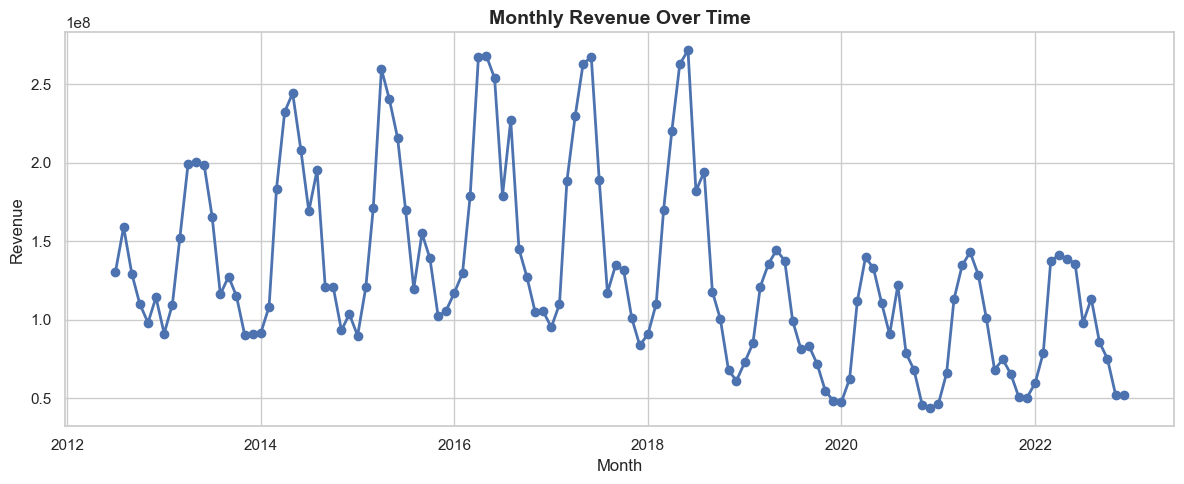

In [12]:
monthly_revenue = daily_metrics.dropna(subset=["date"]).set_index("date")["revenue"].resample("MS").sum().reset_index()

plt.figure(figsize=PLOT_SIZE)
plt.plot(monthly_revenue["date"], monthly_revenue["revenue"], marker="o", linewidth=2)
finish_plot("Monthly Revenue Over Time", "Month", "Revenue", legend=False)

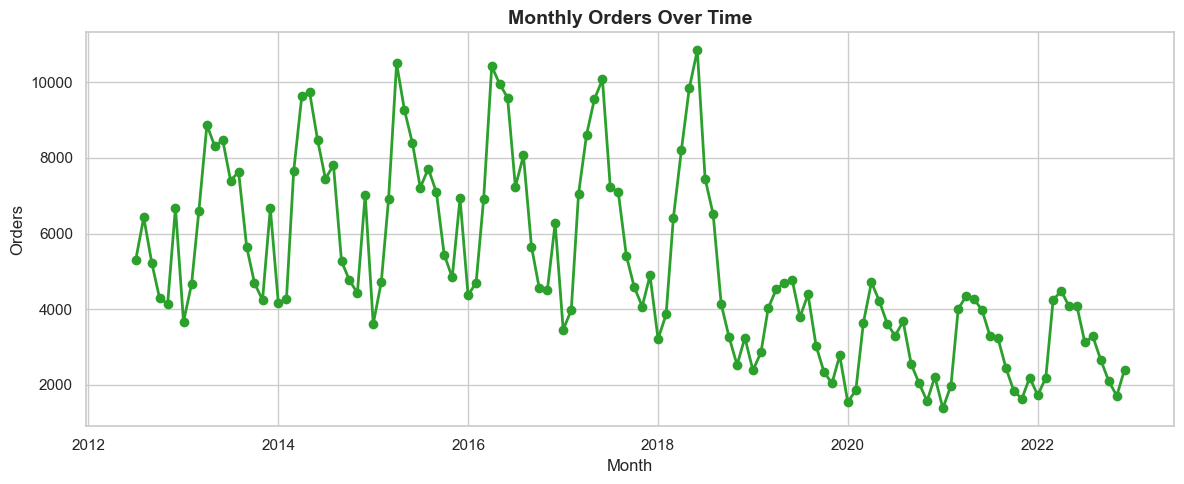

In [13]:
monthly_orders = orders.groupby(pd.Grouper(key="order_date", freq="MS")).agg(orders=("order_id", "nunique")).reset_index()

plt.figure(figsize=PLOT_SIZE)
plt.plot(monthly_orders["order_date"], monthly_orders["orders"], marker="o", color="tab:green", linewidth=2)
finish_plot("Monthly Orders Over Time", "Month", "Orders", legend=False)

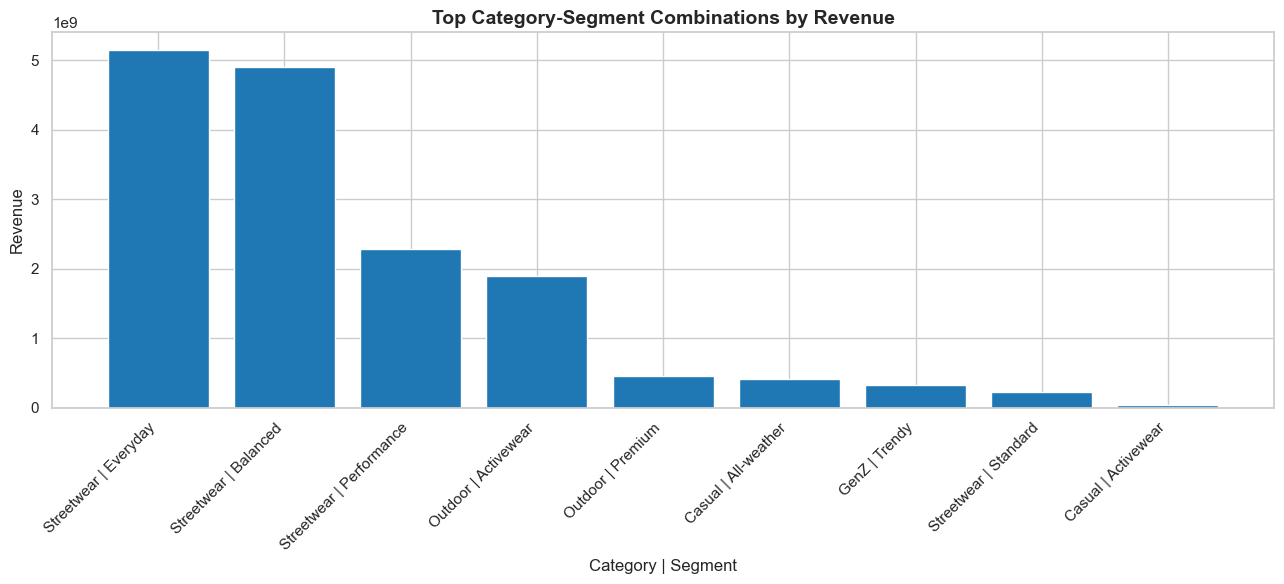

In [14]:
category_segment_revenue = (
    fact_orders.groupby(["category", "segment"], dropna=False)
    .agg(revenue=("line_revenue", "sum"))
    .reset_index()
    .sort_values("revenue", ascending=False)
    .head(20)
)

plt.figure(figsize=(13, 6))
labels = category_segment_revenue["category"].astype(str) + " | " + category_segment_revenue["segment"].astype(str)
plt.bar(labels, category_segment_revenue["revenue"], color="tab:blue")
finish_plot("Top Category-Segment Combinations by Revenue", "Category | Segment", "Revenue", legend=False, rotation=45)

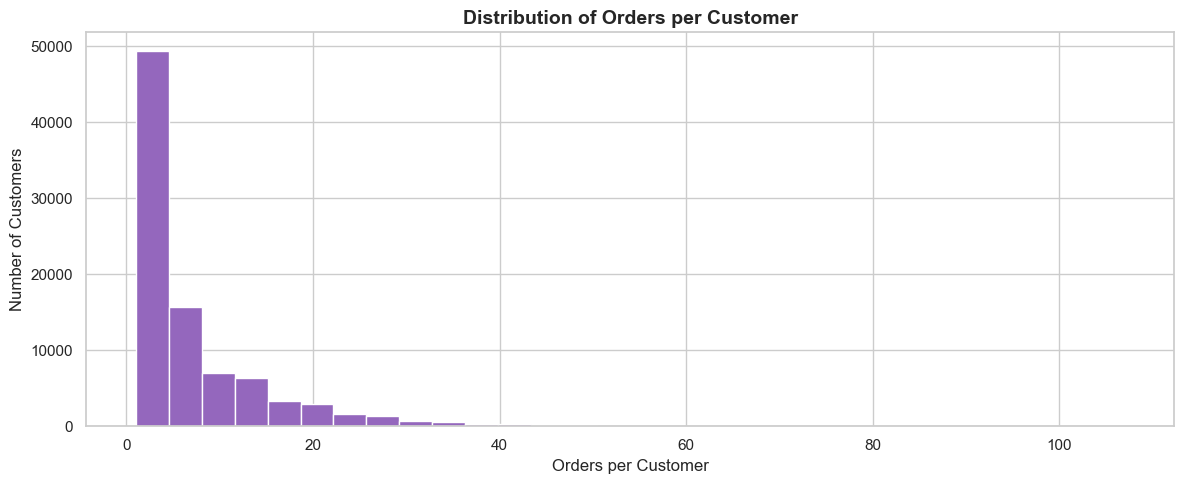

count   90,246.00
mean         7.17
std          8.63
min          1.00
25%          2.00
50%          4.00
75%          9.00
max        107.00
Name: orders, dtype: float64

In [15]:
orders_per_customer = orders.groupby("customer_id").agg(orders=("order_id", "nunique")).reset_index()

plt.figure(figsize=PLOT_SIZE)
plt.hist(orders_per_customer["orders"], bins=30, color="tab:purple", edgecolor="white")
finish_plot("Distribution of Orders per Customer", "Orders per Customer", "Number of Customers", legend=False)

display(orders_per_customer["orders"].describe())

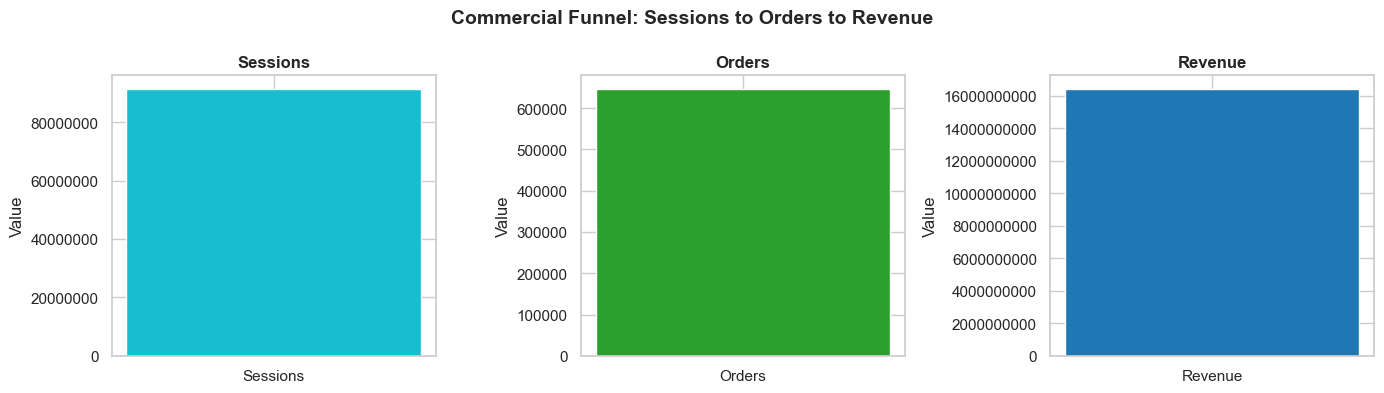

Overall conversion rate: 0.7074%
Revenue per session: 179.66


In [16]:
funnel = pd.DataFrame({
    "stage": ["Sessions", "Orders", "Revenue"],
    "value": [daily_metrics["sessions"].sum(), orders["order_id"].nunique(), daily_metrics["revenue"].sum()],
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["tab:cyan", "tab:green", "tab:blue"]
for ax, (_, row), color in zip(axes, funnel.iterrows(), colors):
    ax.bar(row["stage"], row["value"], color=color)
    ax.set_title(row["stage"], weight="bold")
    ax.set_ylabel("Value")
    ax.ticklabel_format(style="plain", axis="y")
plt.suptitle("Commercial Funnel: Sessions to Orders to Revenue", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

overall_conversion = orders["order_id"].nunique() / daily_metrics["sessions"].sum()
revenue_per_session = daily_metrics["revenue"].sum() / daily_metrics["sessions"].sum()
print(f"Overall conversion rate: {overall_conversion:.4%}")
print(f"Revenue per session: {revenue_per_session:,.2f}")

# Step 4 - Diagnostic Analysis: Why Did It Happen?

This section links performance to likely drivers: promotions, traffic, inventory, returns, and delivery experience.

,has_promo,order_lines,unique_products,revenue,avg_line_revenue,gross_profit,promo_status,revenue_per_product,gross_profit_per_product,gross_margin_pct
0,0,438344,1539,"10,995,039,052.90","25,083.13","2,195,015,385.58",No promotion,"7,144,274.89","1,426,260.81",0.20
1,1,276309,1495,"4,685,830,212.53","16,958.66","-677,596,639.27",Promotion,"3,134,334.59","-453,241.90",-0.14


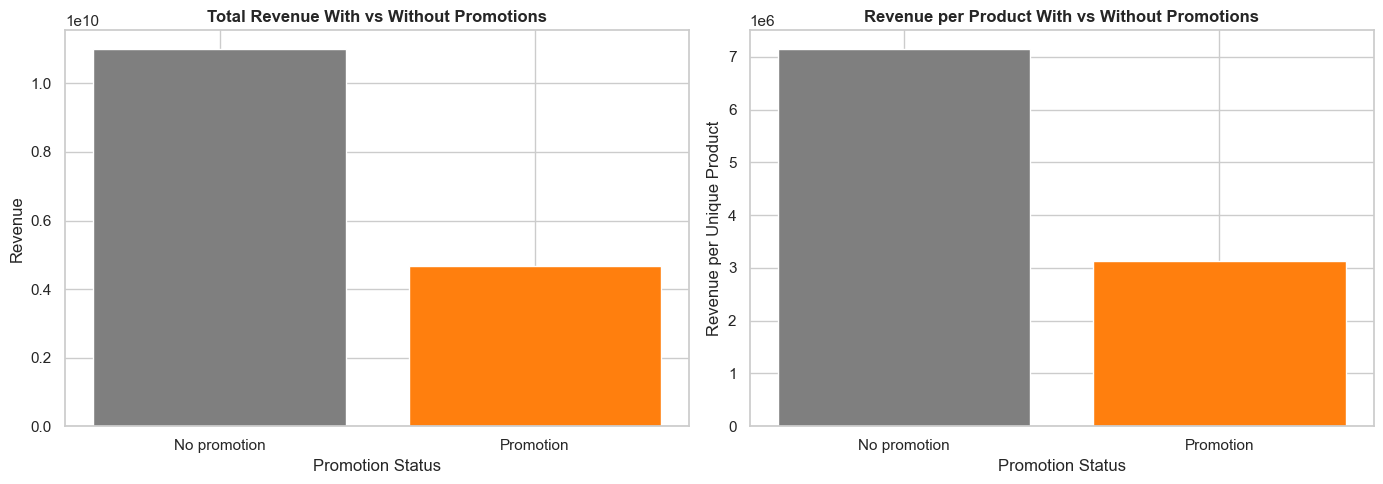

In [17]:
promo_summary = fact_orders.groupby("has_promo").agg(
    order_lines=("product_id", "count"),
    unique_products=("product_id", "nunique"),
    revenue=("line_revenue", "sum"),
    avg_line_revenue=("line_revenue", "mean"),
    gross_profit=("gross_profit", "sum"),
).reset_index()
promo_summary["promo_status"] = promo_summary["has_promo"].map({0: "No promotion", 1: "Promotion"})

# Normalizing by unique product makes the comparison fairer when one group covers many more SKUs.
promo_summary["revenue_per_product"] = promo_summary["revenue"] / promo_summary["unique_products"]
promo_summary["gross_profit_per_product"] = promo_summary["gross_profit"] / promo_summary["unique_products"]
promo_summary["gross_margin_pct"] = promo_summary["gross_profit"] / promo_summary["revenue"]
display(promo_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(promo_summary["promo_status"], promo_summary["revenue"], color=["tab:gray", "tab:orange"])
axes[0].set_title("Total Revenue With vs Without Promotions", weight="bold")
axes[0].set_xlabel("Promotion Status")
axes[0].set_ylabel("Revenue")

axes[1].bar(promo_summary["promo_status"], promo_summary["revenue_per_product"], color=["tab:gray", "tab:orange"])
axes[1].set_title("Revenue per Product With vs Without Promotions", weight="bold")
axes[1].set_xlabel("Promotion Status")
axes[1].set_ylabel("Revenue per Unique Product")

plt.tight_layout()
plt.show()

,promo_type,order_lines,revenue,avg_discount,gross_profit,gross_margin_pct
1,percentage,255359,"4,314,083,021.23","2,916.99","-442,339,347.94",-0.10
0,fixed,20950,"371,747,191.30",225.61,"-235,257,291.33",-0.63


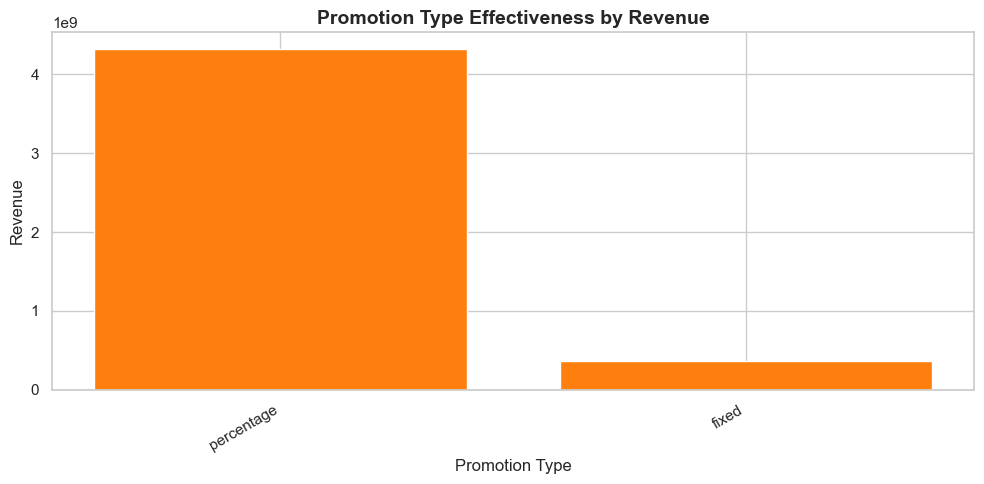

In [18]:
promo_orders = fact_orders.merge(promotions[["promo_id", "promo_type", "discount_value", "promo_channel"]], on="promo_id", how="left")
promo_type_summary = (
    promo_orders[promo_orders["has_promo"] == 1]
    .groupby("promo_type", dropna=False)
    .agg(
        order_lines=("product_id", "count"),
        revenue=("line_revenue", "sum"),
        avg_discount=("discount_amount", "mean"),
        gross_profit=("gross_profit", "sum"),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)
promo_type_summary["gross_margin_pct"] = promo_type_summary["gross_profit"] / promo_type_summary["revenue"]
display(promo_type_summary)

plt.figure(figsize=(10, 5))
plt.bar(promo_type_summary["promo_type"].astype(str), promo_type_summary["revenue"], color="tab:orange")
finish_plot("Promotion Type Effectiveness by Revenue", "Promotion Type", "Revenue", legend=False, rotation=30)

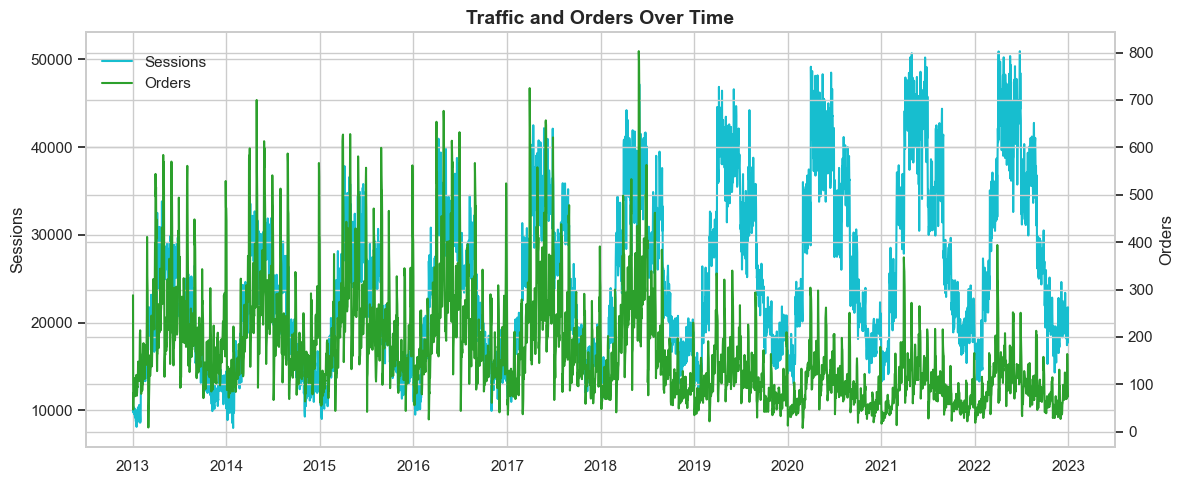

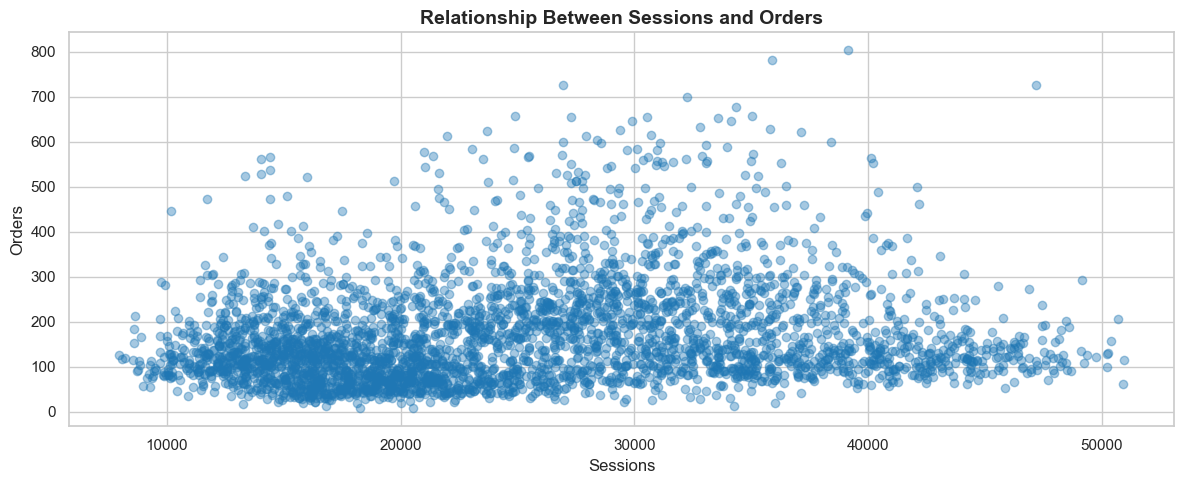

Correlation between sessions and orders: 0.191
Average conversion rate: 0.7356%


In [19]:
traffic_orders = daily_metrics.dropna(subset=["sessions", "orders"]).copy()
traffic_orders["conversion_rate"] = traffic_orders["orders"] / traffic_orders["sessions"]

fig, ax1 = plt.subplots(figsize=PLOT_SIZE)
ax1.plot(traffic_orders["date"], traffic_orders["sessions"], color="tab:cyan", label="Sessions")
ax1.set_ylabel("Sessions")
ax2 = ax1.twinx()
ax2.plot(traffic_orders["date"], traffic_orders["orders"], color="tab:green", label="Orders")
ax2.set_ylabel("Orders")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.9), frameon=False)
plt.title("Traffic and Orders Over Time", fontsize=14, weight="bold")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

plt.figure(figsize=PLOT_SIZE)
plt.scatter(traffic_orders["sessions"], traffic_orders["orders"], alpha=0.4, color="tab:blue")
finish_plot("Relationship Between Sessions and Orders", "Sessions", "Orders", legend=False)

print(f"Correlation between sessions and orders: {traffic_orders['sessions'].corr(traffic_orders['orders']):.3f}")
print(f"Average conversion rate: {traffic_orders['conversion_rate'].mean():.4%}")

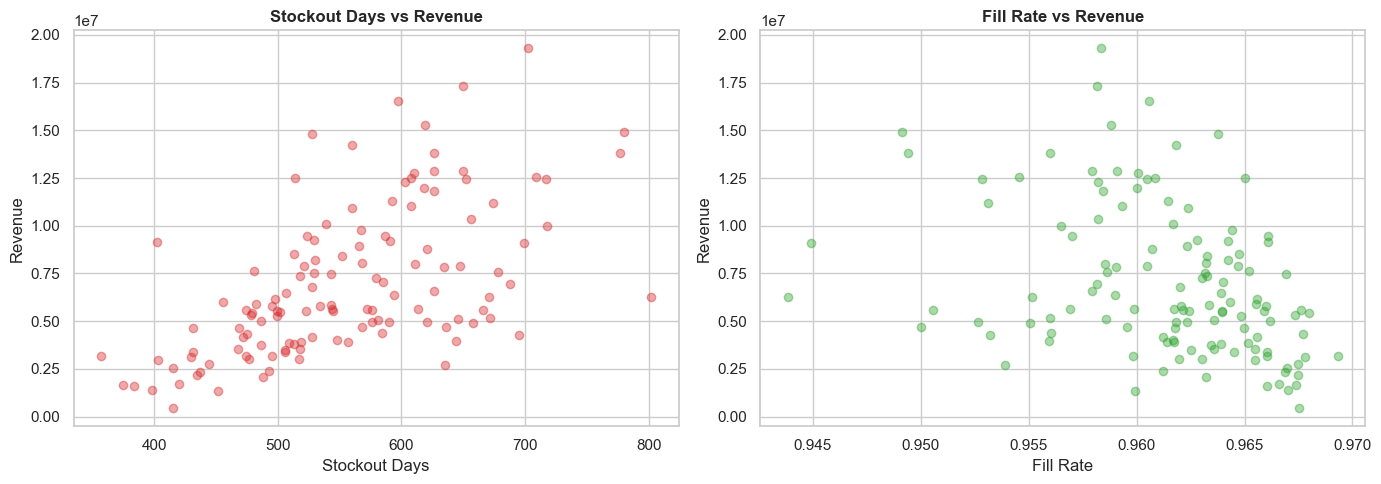

Correlation stockout_days vs revenue: 0.589
Correlation fill_rate vs revenue: -0.363


In [20]:
inv_revenue = daily_metrics.dropna(subset=["revenue", "stockout_days", "fill_rate"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(inv_revenue["stockout_days"], inv_revenue["revenue"], alpha=0.4, color="tab:red")
axes[0].set_title("Stockout Days vs Revenue", weight="bold")
axes[0].set_xlabel("Stockout Days")
axes[0].set_ylabel("Revenue")

axes[1].scatter(inv_revenue["fill_rate"], inv_revenue["revenue"], alpha=0.4, color="tab:green")
axes[1].set_title("Fill Rate vs Revenue", weight="bold")
axes[1].set_xlabel("Fill Rate")
axes[1].set_ylabel("Revenue")
plt.tight_layout()
plt.show()

print(f"Correlation stockout_days vs revenue: {inv_revenue['stockout_days'].corr(inv_revenue['revenue']):.3f}")
print(f"Correlation fill_rate vs revenue: {inv_revenue['fill_rate'].corr(inv_revenue['revenue']):.3f}")

,category,quantity_sold,quantity_returned,return_rate
1,GenZ,166848,"5,869.00",0.04
2,Outdoor,1170000,"40,417.00",0.03
3,Streetwear,1768826,"59,801.00",0.03
0,Casual,107469,"3,499.00",0.03


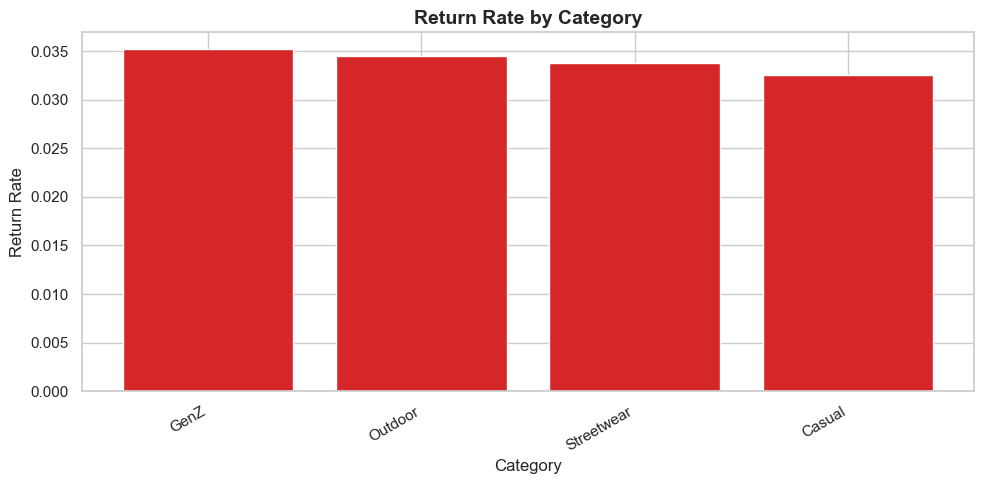

In [21]:
sold_by_product = fact_orders.groupby(["product_id", "category", "size"], dropna=False).agg(quantity_sold=("quantity", "sum")).reset_index()
returned_by_product = fact_returns.groupby(["product_id", "category", "size"], dropna=False).agg(quantity_returned=("return_quantity", "sum")).reset_index()
return_rate = sold_by_product.merge(returned_by_product, on=["product_id", "category", "size"], how="left")
return_rate["quantity_returned"] = return_rate["quantity_returned"].fillna(0)
return_rate["return_rate"] = return_rate["quantity_returned"] / return_rate["quantity_sold"]

category_return_rate = return_rate.groupby("category", dropna=False).agg(
    quantity_sold=("quantity_sold", "sum"),
    quantity_returned=("quantity_returned", "sum"),
).reset_index()
category_return_rate["return_rate"] = category_return_rate["quantity_returned"] / category_return_rate["quantity_sold"]
category_return_rate = category_return_rate.sort_values("return_rate", ascending=False)

display(category_return_rate)

plt.figure(figsize=(10, 5))
plt.bar(category_return_rate["category"].astype(str), category_return_rate["return_rate"], color="tab:red")
finish_plot("Return Rate by Category", "Category", "Return Rate", legend=False, rotation=30)

,size,quantity_sold,quantity_returned,return_rate
2,S,774468,"26,797.00",0.03
0,L,778599,"26,688.00",0.03
1,M,792889,"26,932.00",0.03
3,XL,867187,"29,169.00",0.03


,return_reason,count
0,wrong_size,13967
1,defective,8020
2,not_as_described,7035
3,changed_mind,6931
4,late_delivery,3986


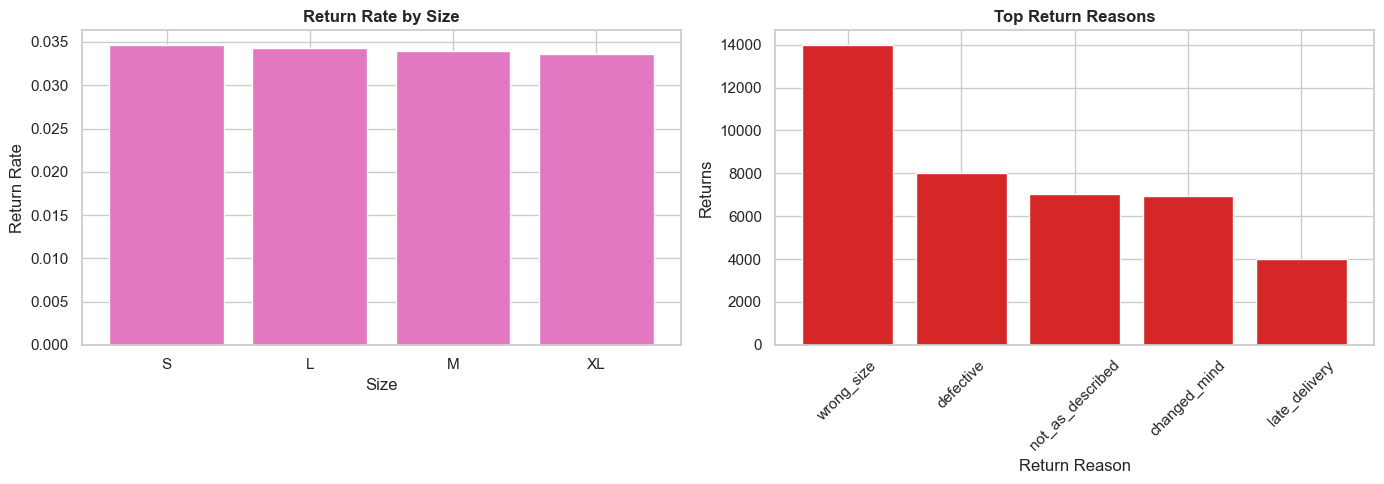

In [22]:
size_return_rate = return_rate.groupby("size", dropna=False).agg(
    quantity_sold=("quantity_sold", "sum"),
    quantity_returned=("quantity_returned", "sum"),
).reset_index()
size_return_rate["return_rate"] = size_return_rate["quantity_returned"] / size_return_rate["quantity_sold"]
size_return_rate = size_return_rate.sort_values("return_rate", ascending=False)

reason_counts = fact_returns["return_reason"].value_counts(dropna=False).reset_index()
reason_counts.columns = ["return_reason", "count"]

display(size_return_rate)
display(reason_counts.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(size_return_rate["size"].astype(str), size_return_rate["return_rate"], color="tab:pink")
axes[0].set_title("Return Rate by Size", weight="bold")
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Return Rate")

axes[1].bar(reason_counts.head(10)["return_reason"].astype(str), reason_counts.head(10)["count"], color="tab:red")
axes[1].set_title("Top Return Reasons", weight="bold")
axes[1].set_xlabel("Return Reason")
axes[1].set_ylabel("Returns")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

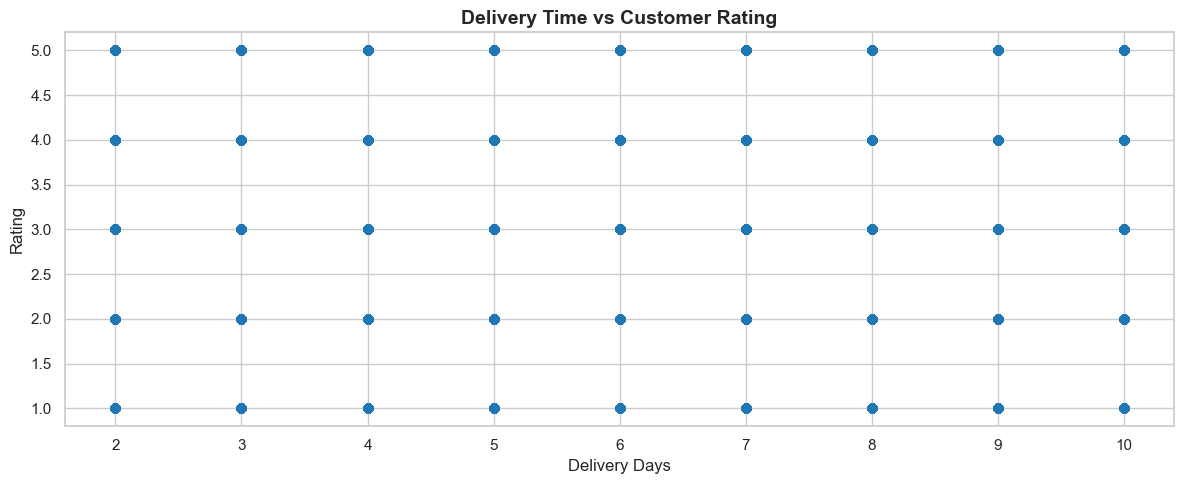

,delivery_days,avg_rating,reviews
5,7.00,3.92,19093
4,6.00,3.95,18898
3,5.00,3.93,18724
2,4.00,3.94,14278
6,8.00,3.94,14132
7,9.00,3.93,9471
1,3.00,3.94,9458
0,2.00,3.95,4781
8,10.00,3.91,4716


Correlation between delivery days and rating: -0.006


In [23]:
delivery_reviews = fact_orders.dropna(subset=["delivery_days", "rating"]).copy()

plt.figure(figsize=PLOT_SIZE)
plt.scatter(delivery_reviews["delivery_days"], delivery_reviews["rating"], alpha=0.25, color="tab:blue")
finish_plot("Delivery Time vs Customer Rating", "Delivery Days", "Rating", legend=False)

rating_by_delivery = delivery_reviews.groupby("delivery_days").agg(avg_rating=("rating", "mean"), reviews=("rating", "count")).reset_index()
display(rating_by_delivery.sort_values("reviews", ascending=False).head(10))
print(f"Correlation between delivery days and rating: {delivery_reviews['delivery_days'].corr(delivery_reviews['rating']):.3f}")

# Step 5 - Predictive Insights: What Will Happen?

This is still EDA, not forecasting. We look for repeatable seasonal patterns, trends, and leading indicators that may help anticipate future revenue movement.

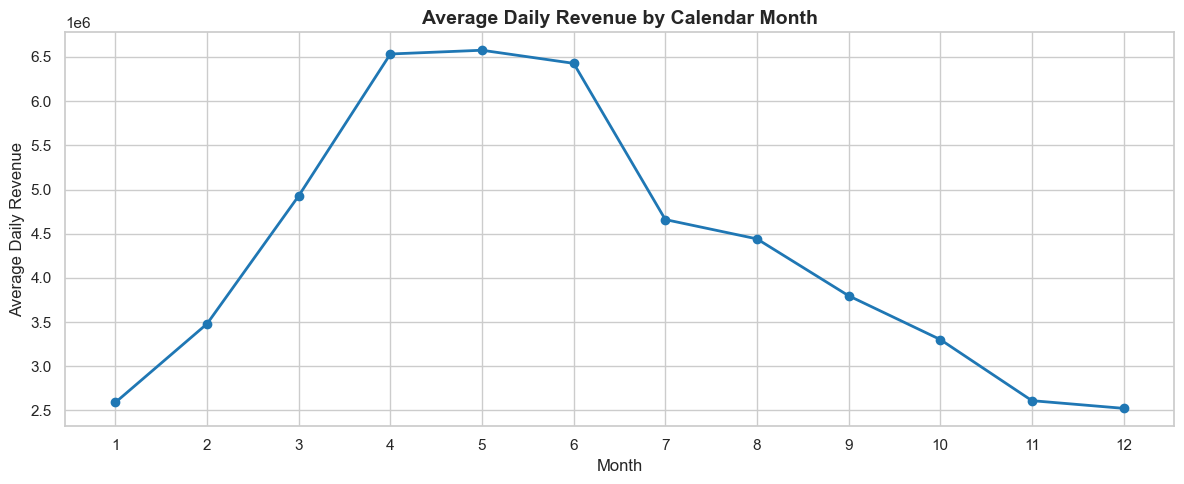

,month,avg_revenue,total_revenue
0,1,"2,591,154.60","803,257,927.41"
1,2,"3,480,800.78","981,585,819.44"
2,3,"4,928,185.47","1,527,737,496.68"
3,4,"6,532,951.88","1,959,885,564.63"
4,5,"6,575,416.35","2,038,379,068.34"
5,6,"6,427,108.65","1,928,132,595.68"
6,7,"4,659,789.37","1,575,008,808.66"
7,8,"4,441,193.49","1,514,446,980.09"
8,9,"3,797,825.60","1,253,282,448.52"
9,10,"3,302,725.22","1,126,229,299.76"


In [24]:
seasonality = daily_metrics.dropna(subset=["date", "revenue"]).copy()
seasonality["month"] = seasonality["date"].dt.month
monthly_pattern = seasonality.groupby("month").agg(avg_revenue=("revenue", "mean"), total_revenue=("revenue", "sum")).reset_index()

plt.figure(figsize=PLOT_SIZE)
plt.plot(monthly_pattern["month"], monthly_pattern["avg_revenue"], marker="o", linewidth=2, color="tab:blue")
plt.xticks(range(1, 13))
finish_plot("Average Daily Revenue by Calendar Month", "Month", "Average Daily Revenue", legend=False)

display(monthly_pattern)

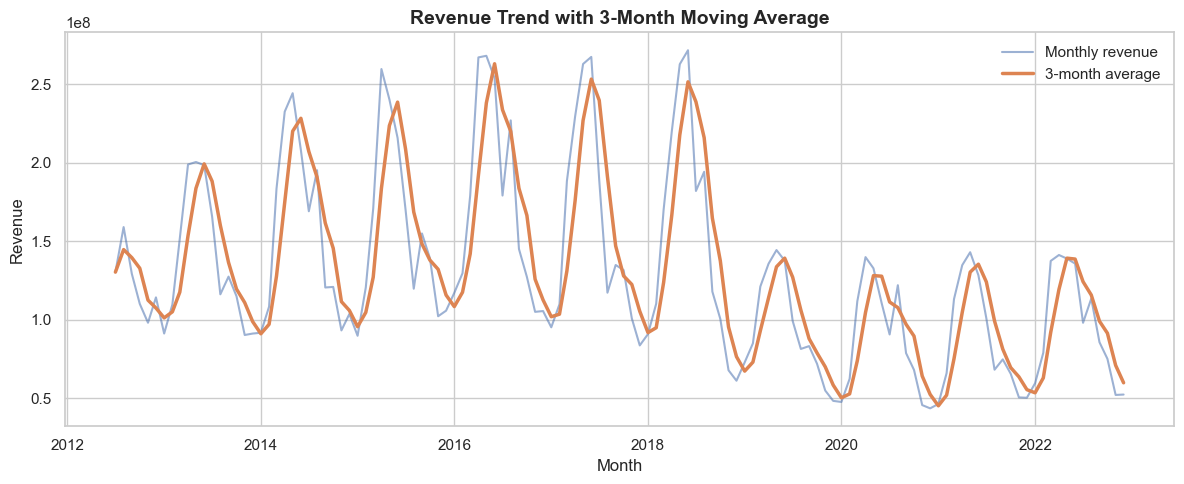

,date,revenue,revenue_3m_avg,mom_growth
114,2022-01-01,"59,663,486.32","53,568,630.71",0.18
115,2022-02-01,"79,103,095.50","63,056,830.06",0.33
116,2022-03-01,"137,537,949.28","92,101,510.37",0.74
117,2022-04-01,"141,305,508.81","119,315,517.86",0.03
118,2022-05-01,"139,027,887.16","139,290,448.42",-0.02
119,2022-06-01,"135,812,426.69","138,715,274.22",-0.02
120,2022-07-01,"98,141,777.72","124,327,363.86",-0.28
121,2022-08-01,"113,542,943.47","115,832,382.63",0.16
122,2022-09-01,"85,764,286.59","99,149,669.26",-0.24
123,2022-10-01,"75,194,452.31","91,500,560.79",-0.12


In [25]:
monthly_trend = monthly_revenue.copy()
monthly_trend["revenue_3m_avg"] = monthly_trend["revenue"].rolling(3, min_periods=1).mean()
monthly_trend["mom_growth"] = monthly_trend["revenue"].pct_change()

plt.figure(figsize=PLOT_SIZE)
plt.plot(monthly_trend["date"], monthly_trend["revenue"], label="Monthly revenue", alpha=0.55)
plt.plot(monthly_trend["date"], monthly_trend["revenue_3m_avg"], label="3-month average", linewidth=2.5)
finish_plot("Revenue Trend with 3-Month Moving Average", "Month", "Revenue", legend=True)

display(monthly_trend.tail(12))

,sessions_7d_vs_next_7d_revenue,stockout_days_7d_vs_next_7d_revenue
0,0.37,0.51


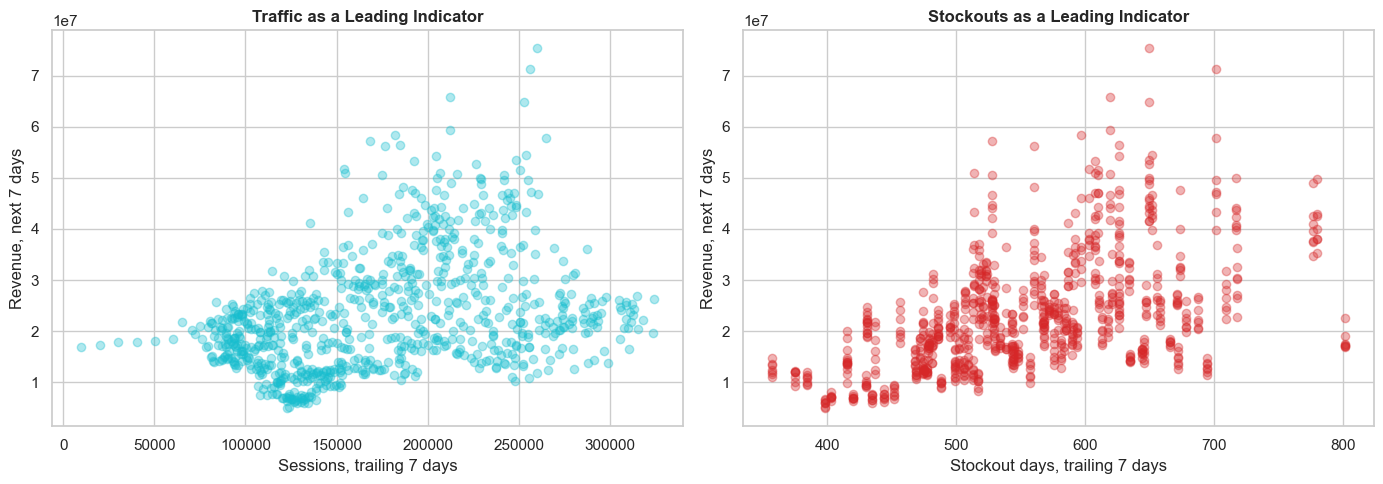

In [26]:
lead_df = daily_metrics.sort_values("date").copy()
lead_df["revenue_next_7d"] = lead_df["revenue"].rolling(7, min_periods=1).sum().shift(-7)
lead_df["sessions_7d"] = lead_df["sessions"].rolling(7, min_periods=1).sum()
lead_df["stockout_days_7d"] = lead_df["stockout_days"].rolling(7, min_periods=1).sum()

leading_corr = {
    "sessions_7d_vs_next_7d_revenue": lead_df["sessions_7d"].corr(lead_df["revenue_next_7d"]),
    "stockout_days_7d_vs_next_7d_revenue": lead_df["stockout_days_7d"].corr(lead_df["revenue_next_7d"]),
}
display(pd.DataFrame([leading_corr]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = lead_df.dropna(subset=["revenue_next_7d", "sessions_7d", "stockout_days_7d"])
axes[0].scatter(plot_df["sessions_7d"], plot_df["revenue_next_7d"], alpha=0.35, color="tab:cyan")
axes[0].set_title("Traffic as a Leading Indicator", weight="bold")
axes[0].set_xlabel("Sessions, trailing 7 days")
axes[0].set_ylabel("Revenue, next 7 days")

axes[1].scatter(plot_df["stockout_days_7d"], plot_df["revenue_next_7d"], alpha=0.35, color="tab:red")
axes[1].set_title("Stockouts as a Leading Indicator", weight="bold")
axes[1].set_xlabel("Stockout days, trailing 7 days")
axes[1].set_ylabel("Revenue, next 7 days")
plt.tight_layout()
plt.show()

### Predictive EDA Interpretation Guide

Use the outputs above to write observations such as:

- Months with consistently higher average revenue indicate seasonal demand peaks.
- A rising 3-month moving average indicates growth; a falling one indicates decline.
- If trailing sessions correlate with future revenue, marketing traffic can be used as an early demand signal.
- If stockout days correlate negatively with future revenue, inventory availability may be limiting near-term sales.

These are directional insights only. They should guide business questions and future modeling, not be treated as a formal forecast.

# Step 6 - Prescriptive Insights: What Should We Do?

This section converts the EDA into business actions. The code below automatically builds evidence tables from the notebook outputs, then frames recommended actions and expected impacts.

In [27]:
recommendations = []

if not inv_revenue.empty:
    stockout_corr = inv_revenue["stockout_days"].corr(inv_revenue["revenue"])
    fill_corr = inv_revenue["fill_rate"].corr(inv_revenue["revenue"])
    recommendations.append({
        "area": "Inventory optimization",
        "insight": "Inventory availability appears connected to revenue performance.",
        "evidence": f"Correlation: stockout_days vs revenue = {stockout_corr:.3f}; fill_rate vs revenue = {fill_corr:.3f}.",
        "business_action": "Prioritize replenishment for high-revenue categories with frequent stockouts; set alert thresholds for low fill_rate products.",
        "expected_impact": "Reduce lost sales and improve customer ability to purchase in-demand products.",
    })

if not promo_type_summary.empty:
    best_promo = promo_type_summary.sort_values("revenue", ascending=False).iloc[0]
    recommendations.append({
        "area": "Promotion targeting",
        "insight": "Promotion performance differs by promotion type.",
        "evidence": f"Top promo_type by revenue: {best_promo['promo_type']} with revenue {best_promo['revenue']:,.0f}.",
        "business_action": "Scale promotion types that lift revenue while monitoring gross margin; reduce broad discounts that do not protect profit.",
        "expected_impact": "Improve promotional ROI and avoid unnecessary margin leakage.",
    })

if not traffic_orders.empty:
    conversion_rate = traffic_orders["conversion_rate"].mean()
    sessions_orders_corr = traffic_orders["sessions"].corr(traffic_orders["orders"])
    recommendations.append({
        "area": "UX and acquisition quality",
        "insight": "Traffic does not automatically become orders; conversion needs separate management.",
        "evidence": f"Average conversion rate = {conversion_rate:.3%}; sessions-orders correlation = {sessions_orders_corr:.3f}.",
        "business_action": "Review landing pages, checkout friction, device experience, and traffic source quality on low-conversion days.",
        "expected_impact": "Increase orders without requiring proportional increases in marketing spend.",
    })

if not category_return_rate.empty:
    worst_category = category_return_rate.iloc[0]
    top_reason = reason_counts.iloc[0] if not reason_counts.empty else None
    recommendations.append({
        "area": "Return reduction",
        "insight": "Returns are concentrated in identifiable product/customer experience areas.",
        "evidence": f"Highest category return rate: {worst_category['category']} at {worst_category['return_rate']:.2%}; top reason: {top_reason['return_reason'] if top_reason is not None else 'N/A'}.",
        "business_action": "Improve size guidance, product detail pages, delivery promises, and quality checks for high-return categories and sizes.",
        "expected_impact": "Reduce refunds, reverse logistics cost, and customer dissatisfaction.",
    })

if not delivery_reviews.empty:
    delivery_rating_corr = delivery_reviews["delivery_days"].corr(delivery_reviews["rating"])
    recommendations.append({
        "area": "Delivery experience",
        "insight": "Delivery speed may influence customer satisfaction.",
        "evidence": f"Correlation between delivery_days and rating = {delivery_rating_corr:.3f}.",
        "business_action": "Monitor late deliveries, improve fulfillment SLAs, and proactively communicate delays to customers.",
        "expected_impact": "Improve ratings, repeat purchase likelihood, and brand trust.",
    })

recommendations_df = pd.DataFrame(recommendations)
display(recommendations_df)

,area,insight,evidence,business_action,expected_impact
0,Inventory optimization,Inventory availability appears connected to re...,Correlation: stockout_days vs revenue = 0.589;...,Prioritize replenishment for high-revenue cate...,Reduce lost sales and improve customer ability...
1,Promotion targeting,Promotion performance differs by promotion type.,Top promo_type by revenue: percentage with rev...,Scale promotion types that lift revenue while ...,Improve promotional ROI and avoid unnecessary ...
2,UX and acquisition quality,Traffic does not automatically become orders; ...,Average conversion rate = 0.736%; sessions-ord...,"Review landing pages, checkout friction, devic...",Increase orders without requiring proportional...
3,Return reduction,Returns are concentrated in identifiable produ...,Highest category return rate: GenZ at 3.52%; t...,"Improve size guidance, product detail pages, d...","Reduce refunds, reverse logistics cost, and cu..."
4,Delivery experience,Delivery speed may influence customer satisfac...,Correlation between delivery_days and rating =...,"Monitor late deliveries, improve fulfillment S...","Improve ratings, repeat purchase likelihood, a..."
